### 1. Data Preprocessing

### 1.1 Load Dataset

In [ ]:
# Import the pandas library for data manipulation
import pandas as pd

# Define the path to the dataset
file_path = '/content/Wholesale customers data.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame to get a glimpse of the data
display(df.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### 1.2 Inspect Dataset Structure

In [ ]:
# Inspect the dataset structure: number of samples (rows), number of features (columns), and data types
# .info() method provides a concise summary of the DataFrame, including data types and non-null values
print('Dataset Information:')
df.info()

# Display the shape of the DataFrame (number of rows, number of columns)
print('\nDataset Shape (rows, columns):')
print(df.shape)

# Display the data types of each column
print('\nData Types:')
print(df.dtypes)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB

Dataset Shape (rows, columns):
(440, 8)

Data Types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object


### 1.3 Check for Missing Values

In [ ]:
# Check for missing values in each column
# .isnull() returns a DataFrame of boolean values indicating missing data
# .sum() counts the number of True values (missing values) for each column
print('Missing Values per Column:')
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

# Observation: If no output, it means there are no missing values in the dataset.

Missing Values per Column:


,0


### 1.4 Remove Duplicate Observations

In [ ]:
# Check for duplicate observations
# .duplicated() returns a boolean Series indicating whether each row is a duplicate of a previous row
print('Number of duplicate rows before removal:')
print(df.duplicated().sum())

# Remove duplicate observations if any are present
# .drop_duplicates(inplace=True) modifies the DataFrame in place
df.drop_duplicates(inplace=True)

# Verify that duplicates have been removed
print('\nNumber of duplicate rows after removal:')
print(df.duplicated().sum())

# Display the shape of the DataFrame after removing duplicates
print('\nDataset Shape after removing duplicates (rows, columns):')
print(df.shape)

Number of duplicate rows before removal:
0

Number of duplicate rows after removal:
0

Dataset Shape after removing duplicates (rows, columns):
(440, 8)


### 1.5 Apply Feature Scaling (Standardization)

In [ ]:
# Apply feature scaling using Standardization
# Standardization (Z-score normalization) transforms data to have a mean of 0 and a standard deviation of 1.
# This is crucial for many machine learning algorithms, including clustering, as it prevents features with larger scales from dominating the process.
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Identify numerical columns to scale (excluding 'Channel' and 'Region' if they are categorical).
# For this dataset, 'Channel' and 'Region' are typically treated as categorical. Let's exclude them from scaling for now.
numerical_cols = df.columns.drop(['Channel', 'Region'])

# Create a copy of the DataFrame for scaled data, keeping 'Channel' and 'Region' as they are.
df_scaled = df.copy()

# Apply StandardScaler to the numerical columns
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display the first few rows of the scaled DataFrame to verify the transformation
print('Scaled DataFrame (first 5 rows):')
display(df_scaled.head())

# Display descriptive statistics of the scaled data to observe mean (close to 0) and std (close to 1)
print('\nDescriptive statistics of scaled numerical features:')
display(df_scaled[numerical_cols].describe())

Scaled DataFrame (first 5 rows):


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,2,3,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,2,3,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,1,3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,2,3,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347



Descriptive statistics of scaled numerical features:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,4.400000e+02,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,-3.431598e-17,0.000000,-4.037175e-17,3.633457e-17,2.422305e-17,-8.074349e-18
std,1.001138e+00,1.001138,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-9.496831e-01,-0.778795,-8.373344e-01,-6.283430e-01,-6.044165e-01,-5.402644e-01
25%,-7.023339e-01,-0.578306,-6.108364e-01,-4.804306e-01,-5.511349e-01,-3.964005e-01
50%,-2.767602e-01,-0.294258,-3.366684e-01,-3.188045e-01,-4.336004e-01,-1.985766e-01
75%,3.905226e-01,0.189092,2.849105e-01,9.946441e-02,2.184822e-01,1.048598e-01
max,7.927738e+00,9.183650,8.936528e+00,1.191900e+01,7.967672e+00,1.647845e+01


### 1.6 Detect Potential Outliers (Box Plots)

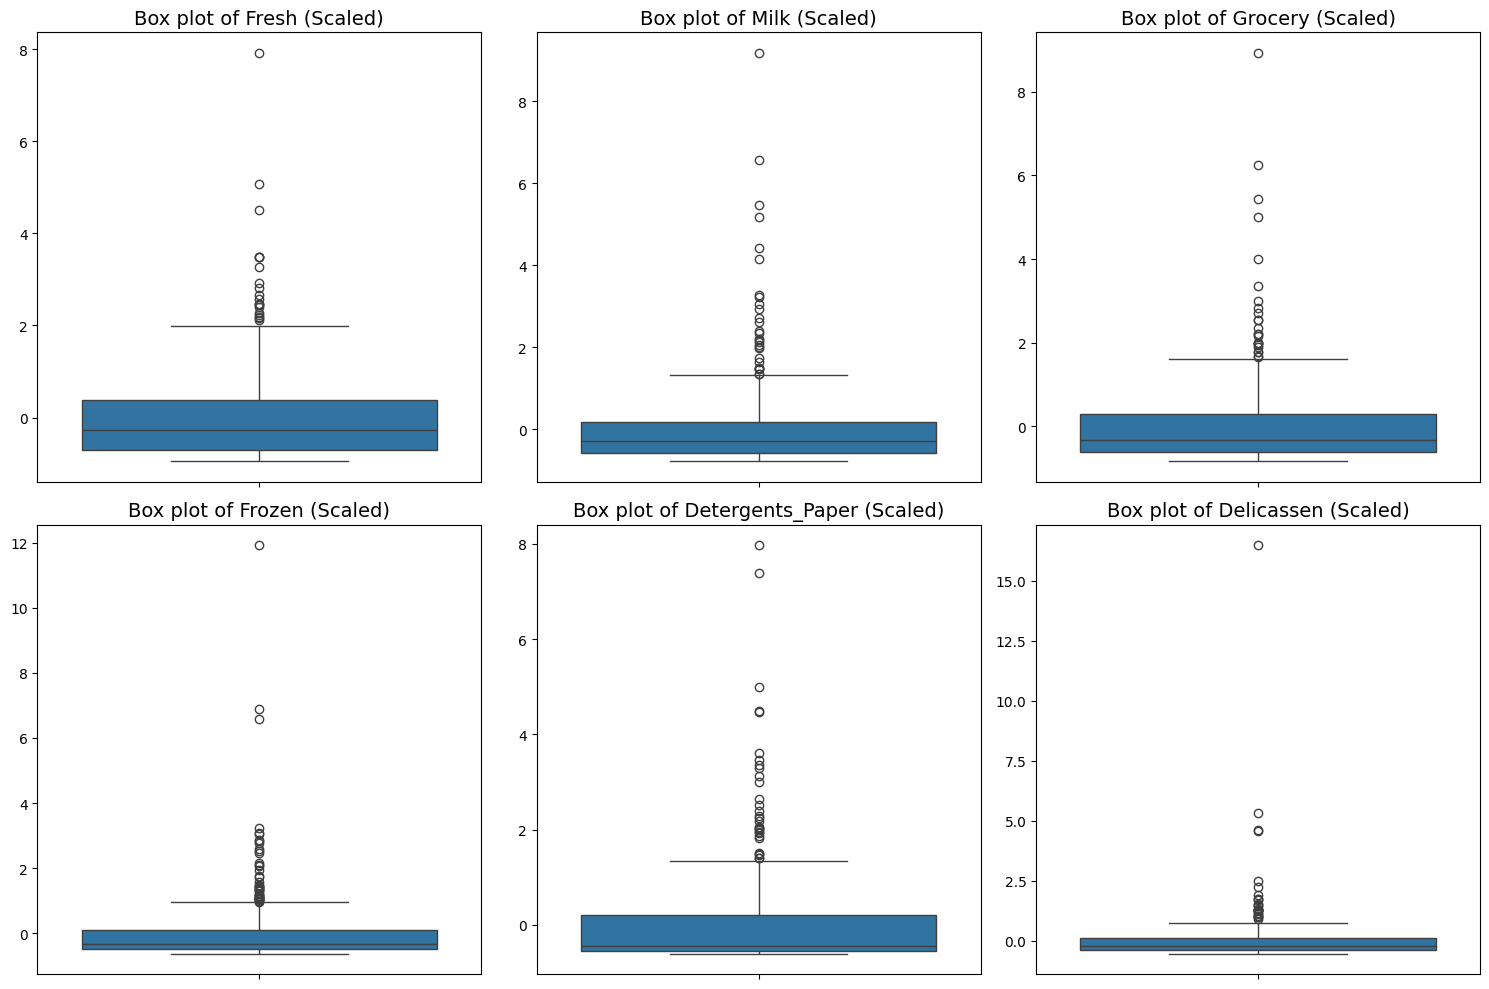

Observation: From the box plots, we can visually identify potential outliers as points extending beyond the 'whiskers'. These will be further investigated or handled if necessary in subsequent steps, depending on the clustering algorithm's sensitivity to outliers.


In [ ]:
# Detect potential outliers using visualization (Box Plots)
# Box plots are a good way to visualize the distribution of numerical data and identify outliers.
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of scaled numerical columns (excluding 'Channel' and 'Region')
numerical_cols_scaled = df_scaled.columns.drop(['Channel', 'Region'])

# Set up the matplotlib figure and axes for the subplots
plt.figure(figsize=(15, 10))

# Create box plots for each scaled numerical feature
for i, col in enumerate(numerical_cols_scaled):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.boxplot(y=df_scaled[col])
    plt.title(f'Box plot of {col} (Scaled)', fontsize=14)
    plt.ylabel('') # Remove y-axis label for cleaner look
plt.tight_layout()
plt.show()

print("Observation: From the box plots, we can visually identify potential outliers as points extending beyond the 'whiskers'. These will be further investigated or handled if necessary in subsequent steps, depending on the clustering algorithm's sensitivity to outliers.")

### 1.7 Apply Dimensionality Reduction (PCA)

Explained variance ratio by each principal component:
Principal Component 1: 0.4408
Principal Component 2: 0.2838
Principal Component 3: 0.1233
Principal Component 4: 0.0940
Principal Component 5: 0.0476
Principal Component 6: 0.0105

Cumulative explained variance:
Up to Principal Component 1: 0.4408
Up to Principal Component 2: 0.7246
Up to Principal Component 3: 0.8479
Up to Principal Component 4: 0.9419
Up to Principal Component 5: 0.9895
Up to Principal Component 6: 1.0000


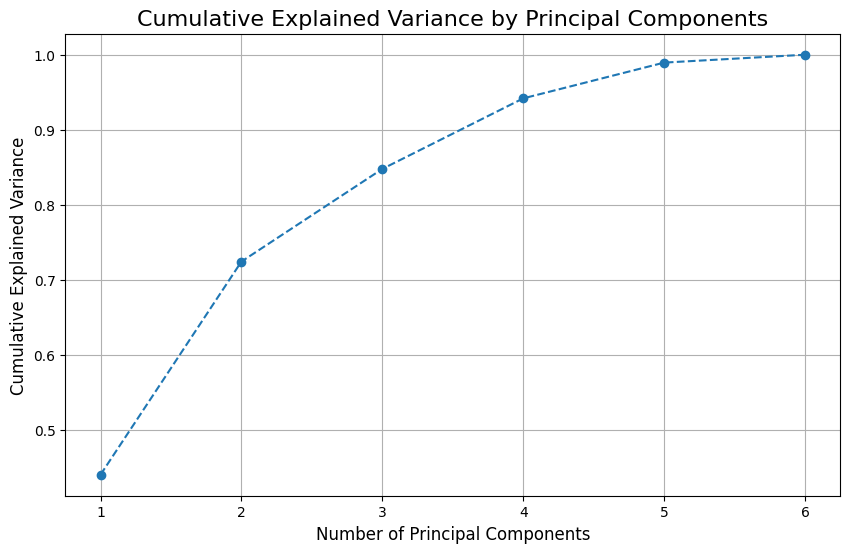

Observation: PCA has been applied. The plot and ratios above help us understand how many components are needed to explain a significant portion of the data's variance. We can choose a subset of these components for dimensionality reduction, typically aiming for 80-95% cumulative variance explained. For visualization, we will typically use 2 or 3 components.


In [ ]:
# Apply dimensionality reduction using Principal Component Analysis (PCA)
# PCA transforms the data into a new coordinate system such that the greatest variance by any projection lies on the first coordinate (called the first principal component),
# the second greatest variance on the second coordinate, and so on.
from sklearn.decomposition import PCA

# Initialize PCA with all components to understand the explained variance
# We'll apply PCA to the scaled numerical features (excluding 'Channel' and 'Region' as these were not scaled).
# It's important to apply PCA on scaled data.

pca = PCA(n_components=None) # Keep all components initially to analyze explained variance

# Fit PCA on the scaled numerical features and transform them
X_pca = pca.fit_transform(df_scaled[numerical_cols])

# Create a DataFrame for PCA results
df_pca = pd.DataFrame(data=X_pca, columns=[f'principal_component_{i+1}' for i in range(X_pca.shape[1])])

# Display the explained variance ratio for each principal component
print('Explained variance ratio by each principal component:')
explained_variance_ratio = pca.explained_variance_ratio_
for i, ratio in enumerate(explained_variance_ratio):
    print(f'Principal Component {i+1}: {ratio:.4f}')

# Display the cumulative explained variance
cumulative_explained_variance = explained_variance_ratio.cumsum()
print('\nCumulative explained variance:')
for i, cum_ratio in enumerate(cumulative_explained_variance):
    print(f'Up to Principal Component {i+1}: {cum_ratio:.4f}')

# Plot the explained variance to help decide the number of components
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components', fontsize=16)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.grid(True)
plt.show()

print("Observation: PCA has been applied. The plot and ratios above help us understand how many components are needed to explain a significant portion of the data's variance. We can choose a subset of these components for dimensionality reduction, typically aiming for 80-95% cumulative variance explained. For visualization, we will typically use 2 or 3 components.")

### 2. Data Visualization

### 2.1 Distribution Plots for Numerical Features

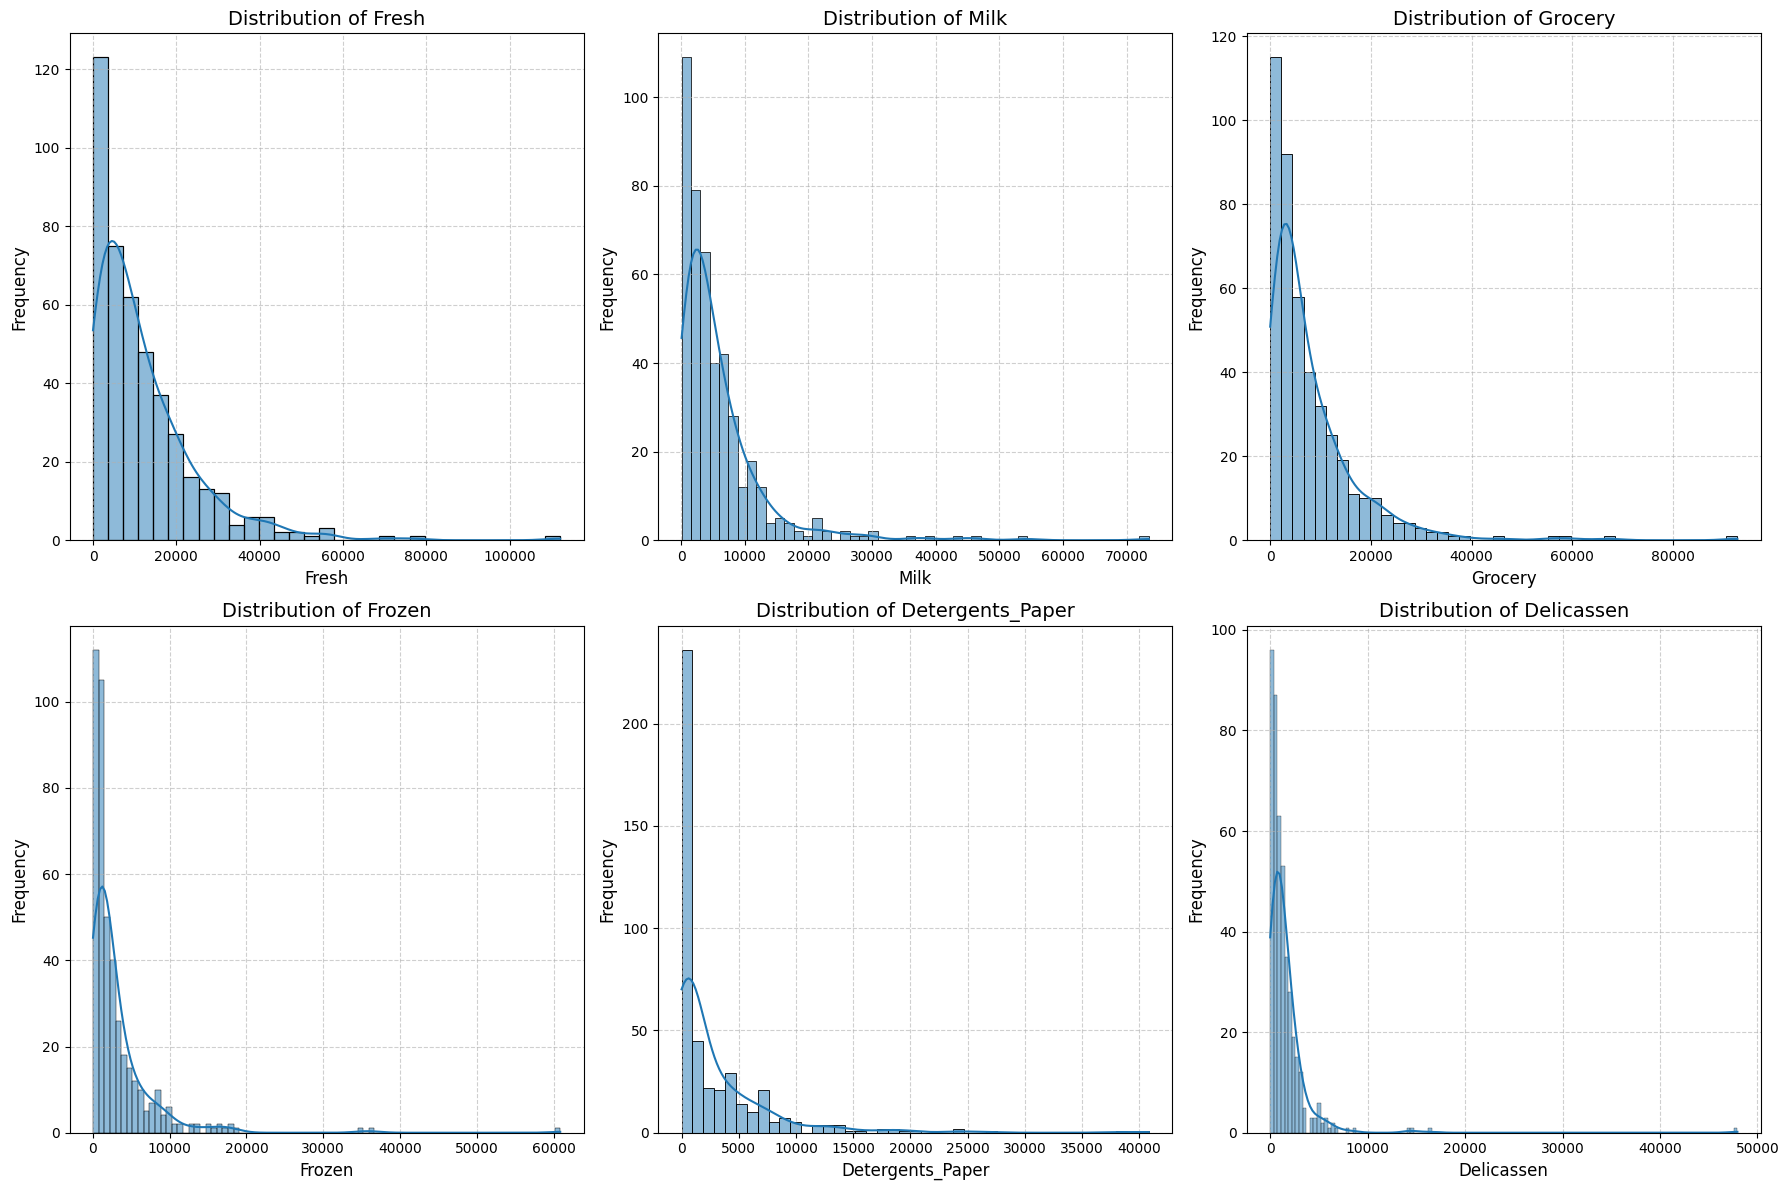

Observation: The distribution plots show the frequency of values for each numerical feature. Some features appear skewed (e.g., Milk, Grocery, Detergents_Paper, Delicassen), indicating a need for potential transformations if a symmetric distribution is desired for certain models. The KDE curve provides a smoothed representation of the data's distribution.


In [ ]:
# Perform exploratory data analysis using visualization techniques:
# Distribution plots for numerical features.

import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numerical columns for distribution plots
# Exclude 'Channel' and 'Region' as they are considered categorical identifiers for this analysis
numerical_features = df.columns.drop(['Channel', 'Region'])

# Set up the matplotlib figure and axes for the subplots
plt.figure(figsize=(18, 12))

# Loop through each numerical feature and create a distribution plot
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical features (6 in this case)
    sns.histplot(df[feature], kde=True) # kde=True adds a kernel density estimate curve
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Observation: The distribution plots show the frequency of values for each numerical feature. Some features appear skewed (e.g., Milk, Grocery, Detergents_Paper, Delicassen), indicating a need for potential transformations if a symmetric distribution is desired for certain models. The KDE curve provides a smoothed representation of the data's distribution.")

### 2.2 Correlation Heatmap

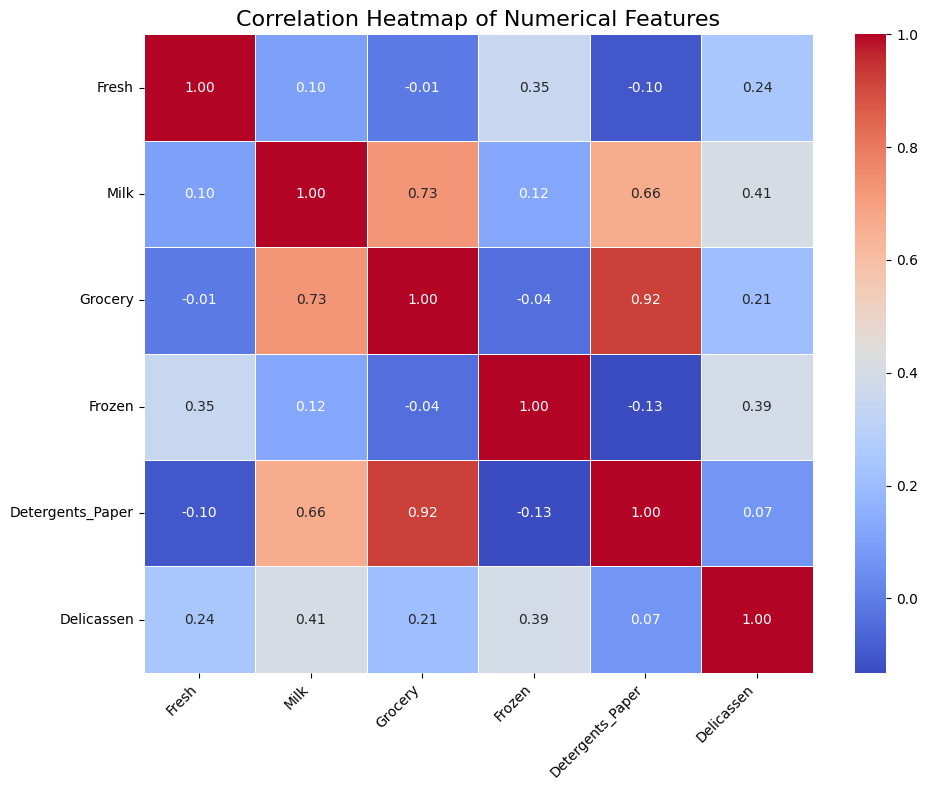

Observation: The correlation heatmap displays the pairwise correlation coefficients between numerical features. Values closer to 1 or -1 indicate strong positive or negative correlations, respectively. Values near 0 suggest weak or no linear relationship. High correlations are observed between 'Milk', 'Grocery', and 'Detergents_Paper', suggesting these items might be purchased together.


In [ ]:
# Perform exploratory data analysis using visualization techniques:
# Correlation heatmap to analyze relationships between variables.

import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numerical columns for correlation analysis
# Exclude 'Channel' and 'Region' if they are considered categorical identifiers
numerical_features_for_corr = df.columns.drop(['Channel', 'Region'])

# Calculate the correlation matrix for the numerical features
correlation_matrix = df[numerical_features_for_corr].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Observation: The correlation heatmap displays the pairwise correlation coefficients between numerical features. Values closer to 1 or -1 indicate strong positive or negative correlations, respectively. Values near 0 suggest weak or no linear relationship. High correlations are observed between 'Milk', 'Grocery', and 'Detergents_Paper', suggesting these items might be purchased together.")

### 2.3 Pairwise Feature Plots

Generating Pairwise Feature Plots... This may take a moment.


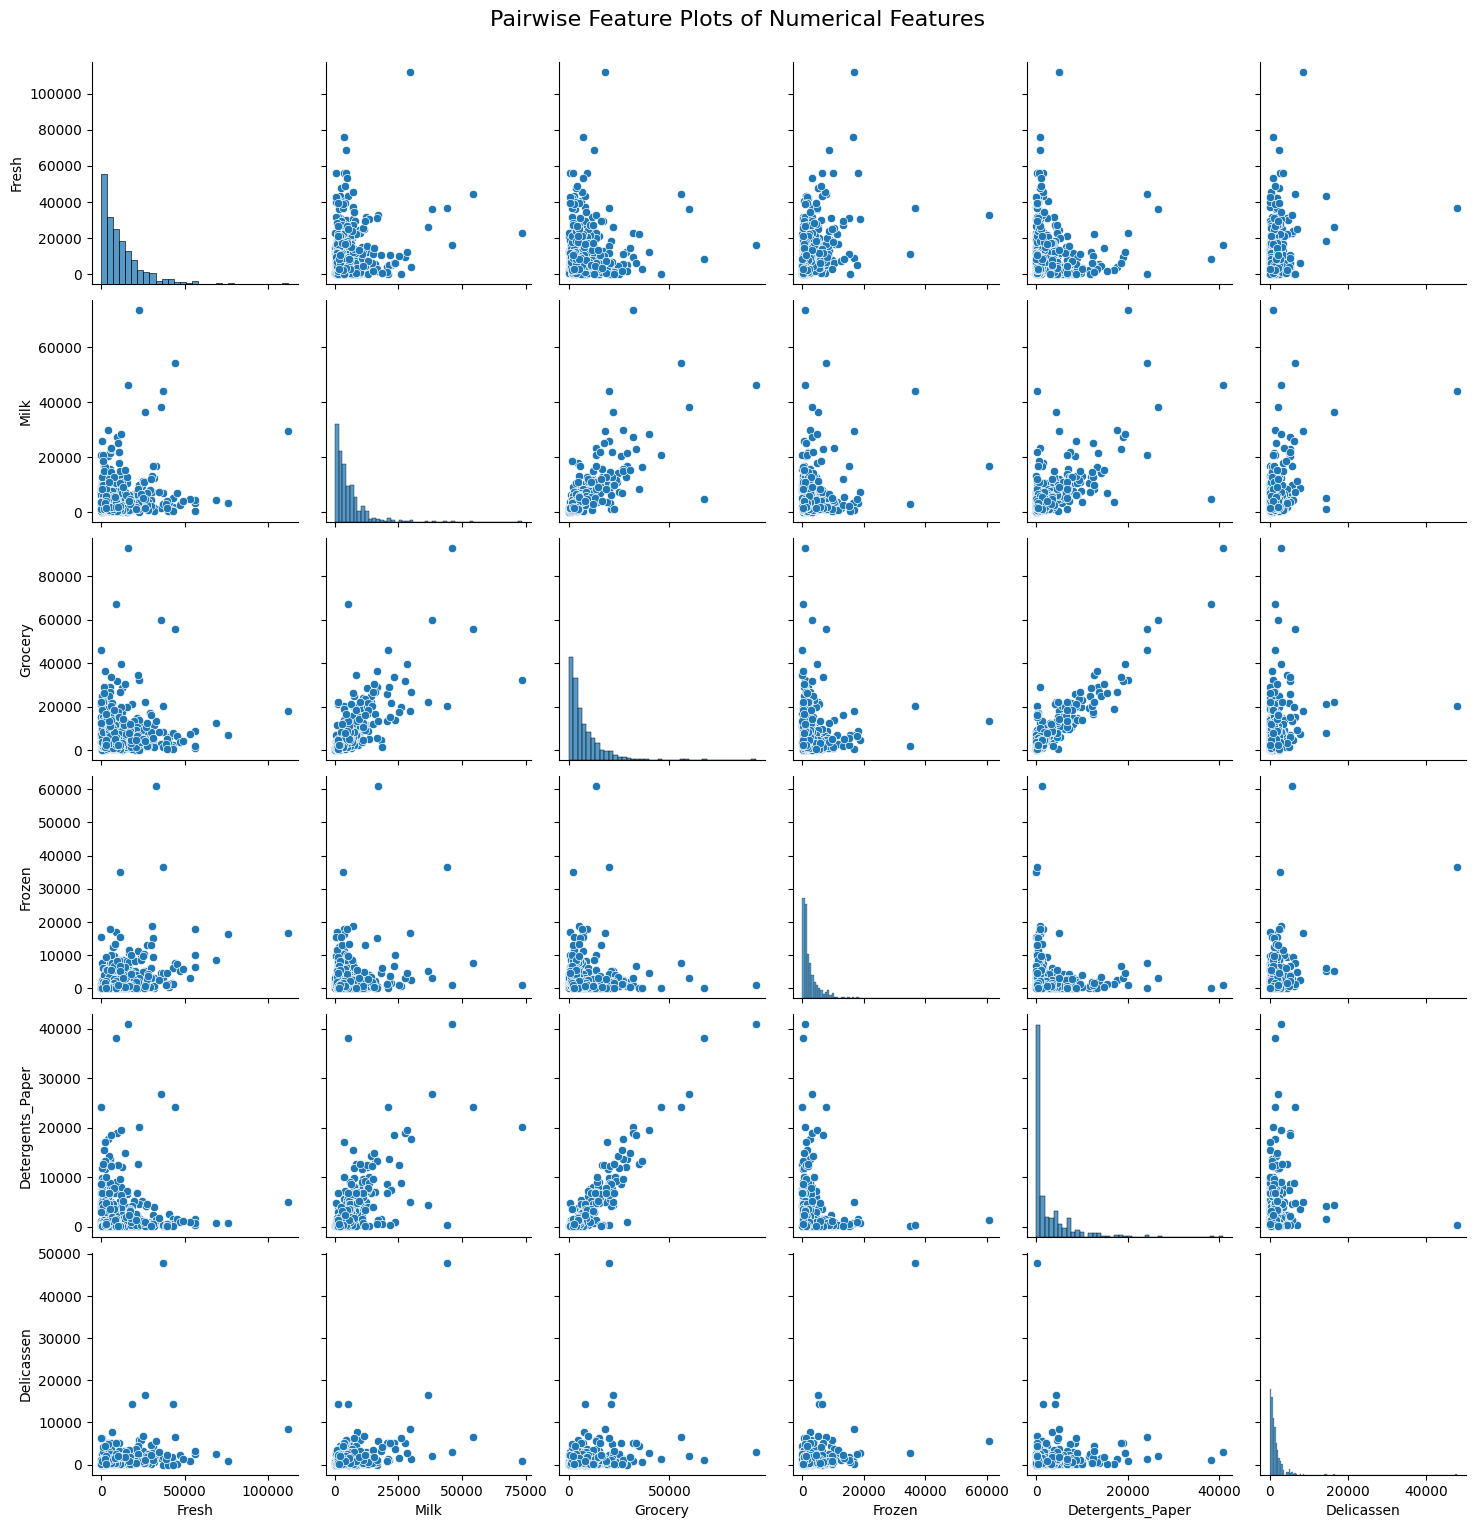

Observation: Pairwise plots provide a matrix of scatter plots showing the relationship between each pair of variables and histograms/KDEs on the diagonal showing the distribution of each variable. This helps in identifying linear or non-linear relationships, clusters, and potential outliers between feature pairs, further confirming strong correlations seen in the heatmap.


In [ ]:
# Perform exploratory data analysis using visualization techniques:
# Pairwise feature plots to observe feature interactions.

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for pairwise plots
# Exclude 'Channel' and 'Region' if they are considered categorical identifiers
numerical_features_for_pairplot = df.columns.drop(['Channel', 'Region'])

# Create a pair plot for the numerical features
# This will generate scatter plots for each pair of features and histograms for individual features.
# Due to the number of features, this plot can be quite large and might take some time to generate.
# For a large number of features, sampling or focusing on specific pairs might be necessary.
print("Generating Pairwise Feature Plots... This may take a moment.")
sns.pairplot(df[numerical_features_for_pairplot])
plt.suptitle('Pairwise Feature Plots of Numerical Features', y=1.02, fontsize=16) # Adjust title position
plt.show()

print("Observation: Pairwise plots provide a matrix of scatter plots showing the relationship between each pair of variables and histograms/KDEs on the diagonal showing the distribution of each variable. This helps in identifying linear or non-linear relationships, clusters, and potential outliers between feature pairs, further confirming strong correlations seen in the heatmap.")

### 2.4 Scatter Plots between Selected Feature Pairs

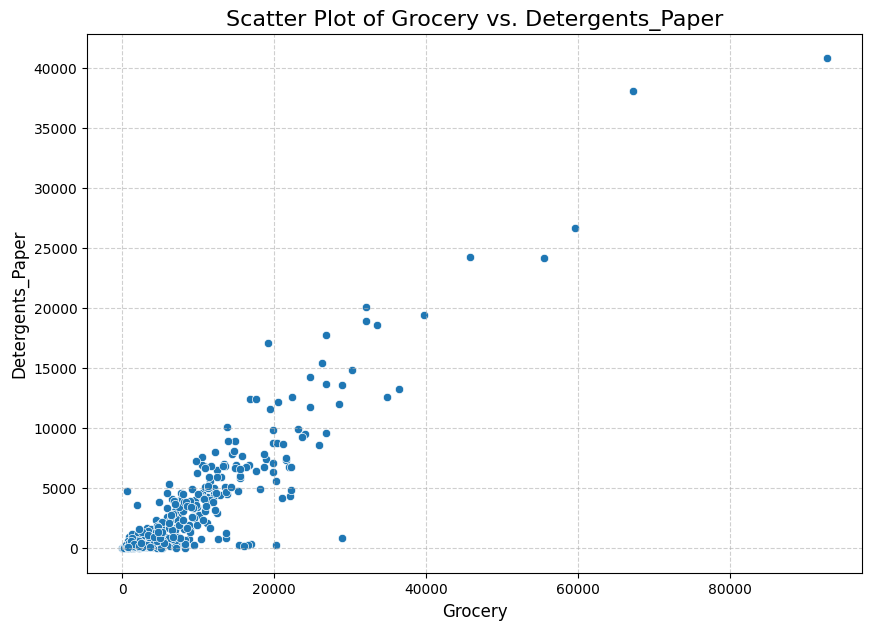

Observation: This scatter plot visualizes the strong positive linear relationship between 'Grocery' and 'Detergents_Paper', as indicated by the correlation heatmap. It confirms that customers who buy more grocery items tend to buy more detergents and paper products.


In [ ]:
# Perform exploratory data analysis using visualization techniques:
# Scatter plots between selected feature pairs.

import matplotlib.pyplot as plt
import seaborn as sns

# Select two features for a scatter plot to observe their interaction
# Choosing 'Grocery' and 'Detergents_Paper' due to their high correlation.
feature_x = 'Grocery'
feature_y = 'Detergents_Paper'

plt.figure(figsize=(10, 7))
sns.scatterplot(x=df[feature_x], y=df[feature_y])
plt.title(f'Scatter Plot of {feature_x} vs. {feature_y}', fontsize=16)
plt.xlabel(feature_x, fontsize=12)
plt.ylabel(feature_y, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Observation: This scatter plot visualizes the strong positive linear relationship between '{feature_x}' and '{feature_y}', as indicated by the correlation heatmap. It confirms that customers who buy more grocery items tend to buy more detergents and paper products.")

### 2.5 Two-dimensional visualization using PCA projection

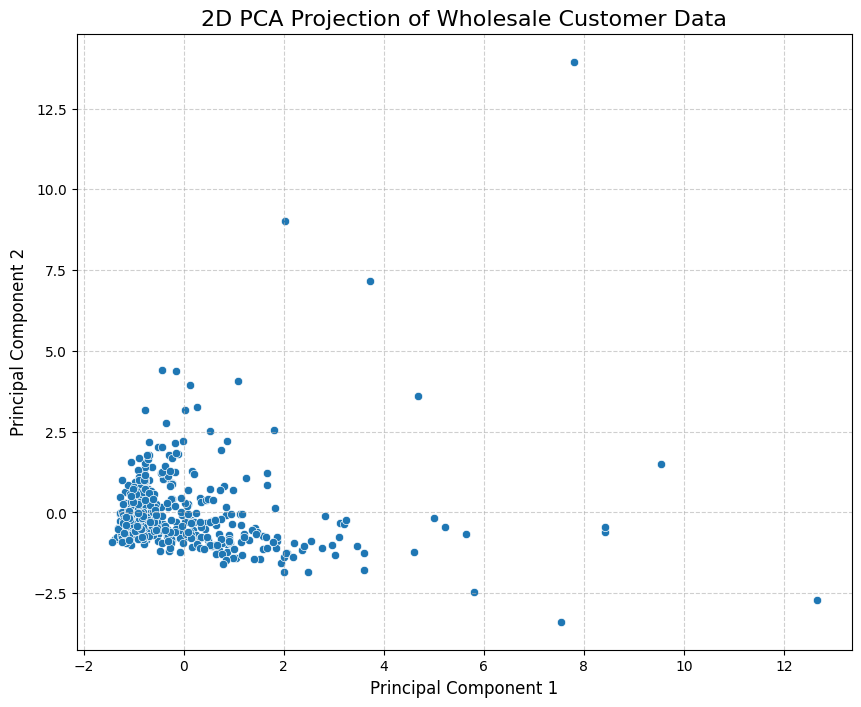

Observation: This scatter plot displays the data projected onto the first two principal components. This 2D view captures the most variance in the dataset and can reveal potential clusters or patterns that are not visible in higher dimensions.


In [ ]:
# Perform exploratory data analysis using visualization techniques:
# Two-dimensional visualization using PCA projection.

import matplotlib.pyplot as plt
import seaborn as sns

# Use the first two principal components from the earlier PCA step for 2D visualization
# df_pca contains 'principal_component_1' and 'principal_component_2'

plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', data=df_pca)
plt.title('2D PCA Projection of Wholesale Customer Data', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: This scatter plot displays the data projected onto the first two principal components. This 2D view captures the most variance in the dataset and can reveal potential clusters or patterns that are not visible in higher dimensions.")

### 2.6 Apply t-SNE to obtain a non-linear two-dimensional visualization of the dataset.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


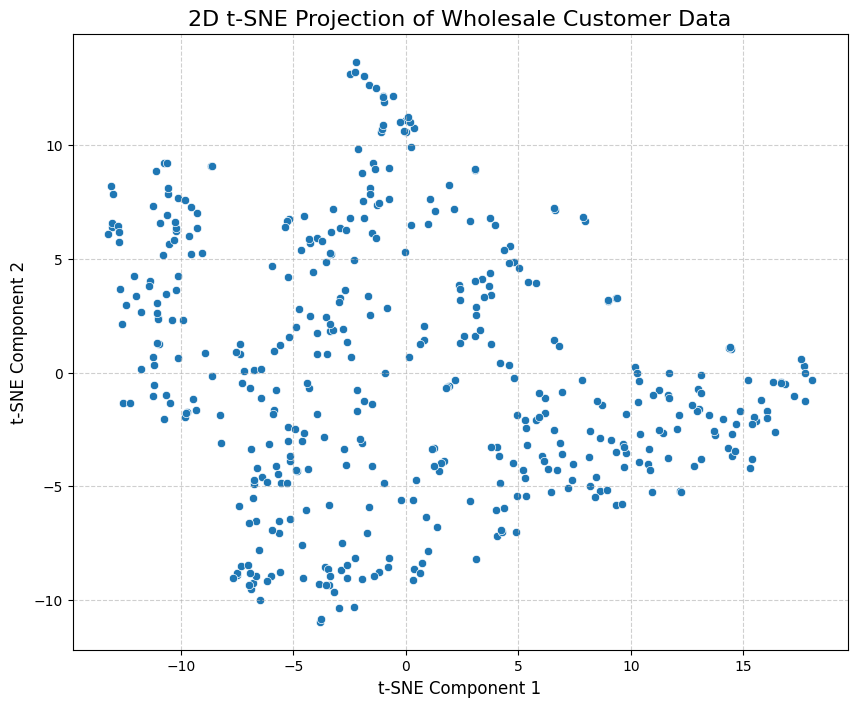

Observation: The t-SNE plot provides a non-linear 2D representation of the dataset, aiming to reveal intrinsic clusters and structures. Compared to PCA, t-SNE often creates more visually distinct groupings if underlying non-linear relationships exist. This visualization can be particularly useful for identifying potential customer segments.


In [ ]:
# Apply t-SNE to obtain a non-linear two-dimensional visualization of the dataset.
# t-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction technique
# particularly well-suited for embedding high-dimensional data into a low-dimensional space of two or three dimensions.
# It aims to preserve local structures, meaning that points that are close in the high-dimensional space remain close in the low-dimensional embedding.

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize t-SNE. Common parameters include:
# n_components: Dimension of the embedded space (usually 2 or 3)
# perplexity: Relates to the number of nearest neighbors used in the algorithm (usually between 5 and 50)
# n_iter: Number of iterations (often 250 to 1000)
# learning_rate: Controls how quickly the algorithm converges
# random_state: For reproducibility
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, learning_rate='auto', random_state=42)

# Apply t-SNE to the scaled numerical data (df_scaled, excluding 'Channel' and 'Region')
# It's important to apply t-SNE on scaled data.
X_tsne = tsne.fit_transform(df_scaled[numerical_cols])

# Create a DataFrame for t-SNE results
df_tsne = pd.DataFrame(data=X_tsne, columns=['tsne_component_1', 'tsne_component_2'])

# Plot the 2D t-SNE projection
plt.figure(figsize=(10, 8))
sns.scatterplot(x='tsne_component_1', y='tsne_component_2', data=df_tsne)
plt.title('2D t-SNE Projection of Wholesale Customer Data', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: The t-SNE plot provides a non-linear 2D representation of the dataset, aiming to reveal intrinsic clusters and structures. Compared to PCA, t-SNE often creates more visually distinct groupings if underlying non-linear relationships exist. This visualization can be particularly useful for identifying potential customer segments.")

### 3. Save Cleaned Dataset

In [ ]:
# Save the cleaned and scaled DataFrame to a new CSV file
# This saves the preprocessed data, ready for further analysis or model building.
output_file_path = 'cleaned_wholesale_customer_data.csv'
df_scaled.to_csv(output_file_path, index=False) # index=False prevents writing the DataFrame index as a column

print(f"Cleaned dataset saved successfully to '{output_file_path}'")

Cleaned dataset saved successfully to 'cleaned_wholesale_customer_data.csv'


# **Clustering Techniques**

In [ ]:
# Import clustering algorithms and evaluation tools
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture

# Import metrics
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# For numerical operations
import numpy as np

In [ ]:
# Load the cleaned dataset (the one you saved earlier)
import pandas as pd

df = pd.read_csv('cleaned_wholesale_customer_data.csv')

# Drop categorical columns if needed for clustering (recommended)
X = df.drop(['Channel', 'Region'], axis=1)

# Display first rows
X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


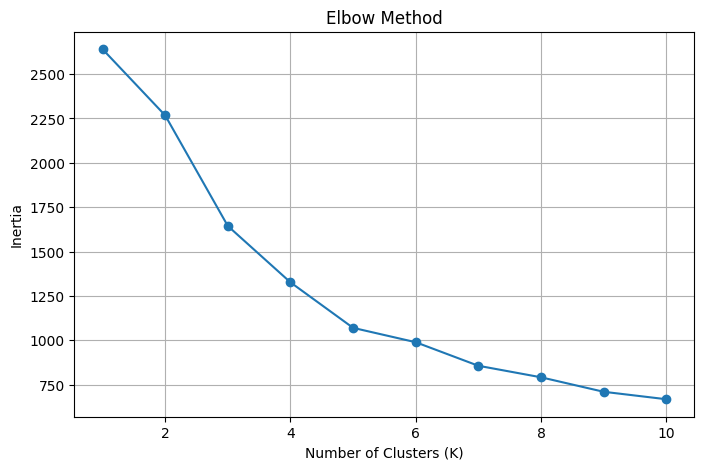

In [ ]:
# Compute inertia for different values of K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [ ]:
# Store K-Means results
kmeans_results = {}

for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fit and predict
    labels = kmeans.fit_predict(X)

    # Store model, labels, and centers
    kmeans_results[k] = {
        'model': kmeans,
        'labels': labels,
        'centers': kmeans.cluster_centers_
    }

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


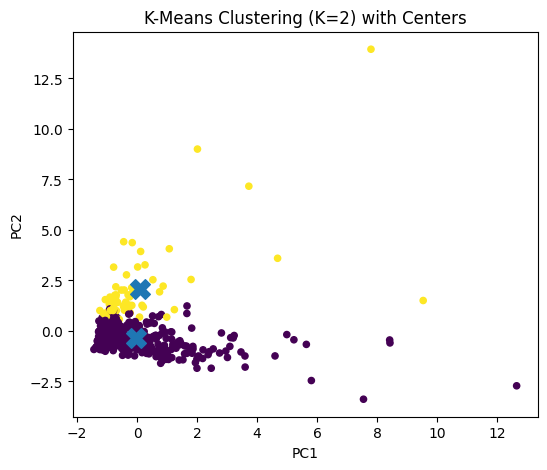

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


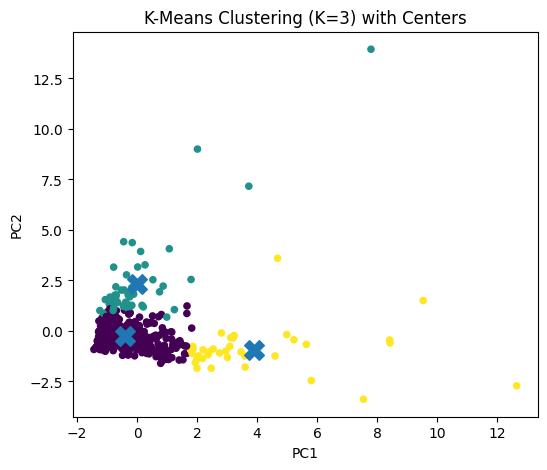

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


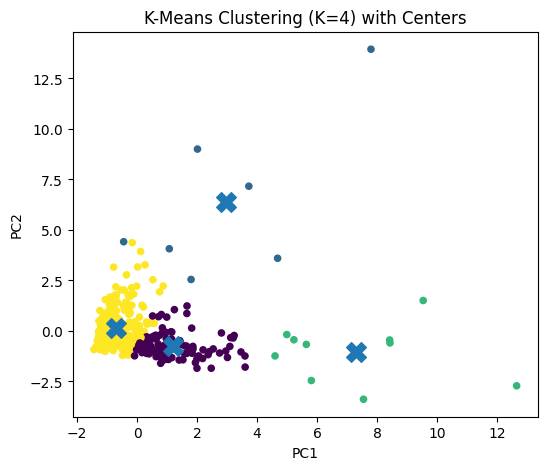

In [ ]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot K-Means clustering with cluster centers

for k in [2, 3, 4]:
    plt.figure(figsize=(6,5))

    labels = kmeans_results[k]['labels']
    centers = kmeans_results[k]['centers']

    # Transform centers into PCA space
    centers_pca = pca.transform(centers)

    # Plot clustered data
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20)

    # Plot cluster centers
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
                s=200, marker='X')

    plt.title(f'K-Means Clustering (K={k}) with Centers')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

In [ ]:
# Store Spectral Clustering results
spectral_results = {}

for k in [2, 3, 4]:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        random_state=42
    )

    labels = spectral.fit_predict(X)

    spectral_results[k] = labels

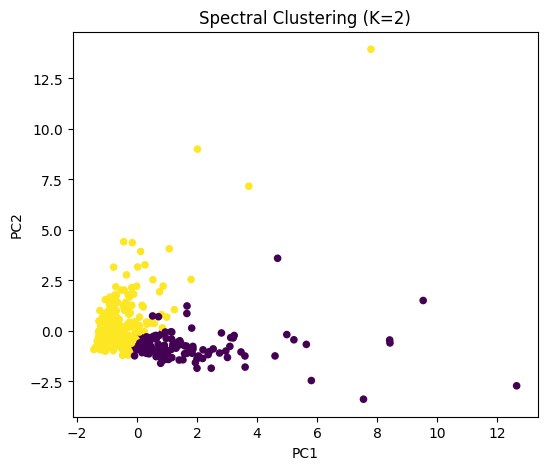

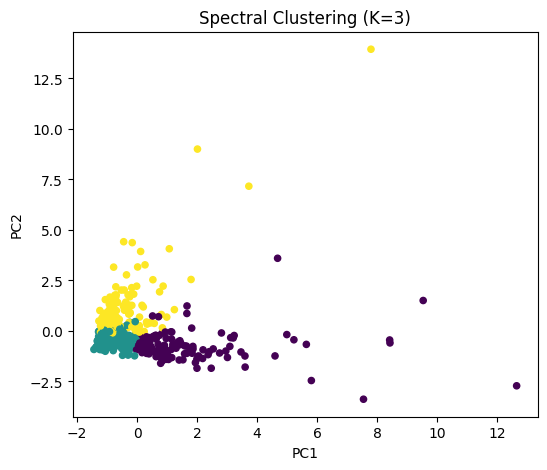

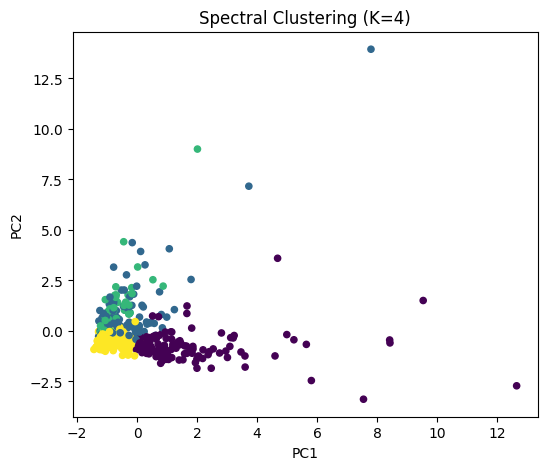

In [ ]:
# Plot Spectral Clustering results

for k in [2, 3, 4]:
    plt.figure(figsize=(6,5))

    labels = spectral_results[k]

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20)

    plt.title(f'Spectral Clustering (K={k})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

In [ ]:
# Store GMM results
gmm_results = {}

for k in [2, 3, 4]:
    gmm = GaussianMixture(n_components=k, random_state=42)

    gmm.fit(X)
    labels = gmm.predict(X)

    gmm_results[k] = {
        'model': gmm,
        'labels': labels
    }

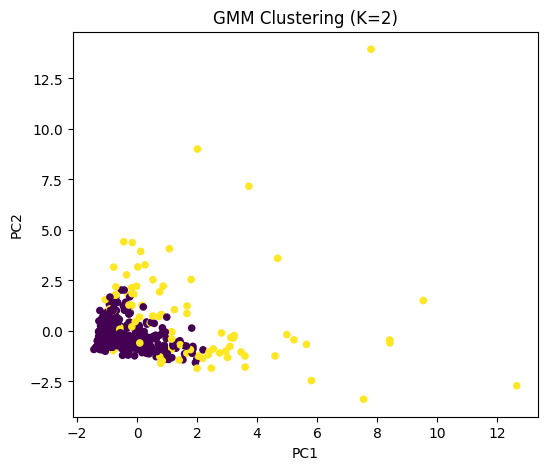

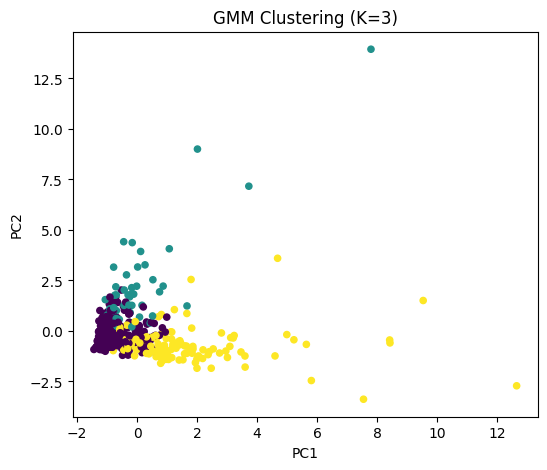

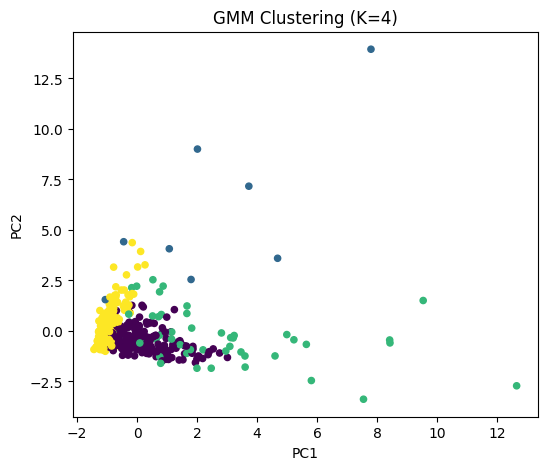

In [ ]:
# Plot GMM clustering results

for k in [2, 3, 4]:
    plt.figure(figsize=(6,5))

    labels = gmm_results[k]['labels']

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=20)

    plt.title(f'GMM Clustering (K={k})')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.show()

*   The Elbow Method helps estimate the optimal number of clusters by identifying the “elbow point” where inertia stops decreasing significantly.
*   K-Means produced clear and compact clusters, especially for lower K values.
*   Spectral Clustering transforms data into a lower-dimensional space using eigenvectors of a similarity matrix.
It is effective for detecting non-linear cluster structures.
Unlike K-Means, it does not assume spherical clusters.
*   GMM provided soft clustering and handled overlapping clusters better than K-Means.
*   PCA visualization helped in comparing clustering structures across algorithms.

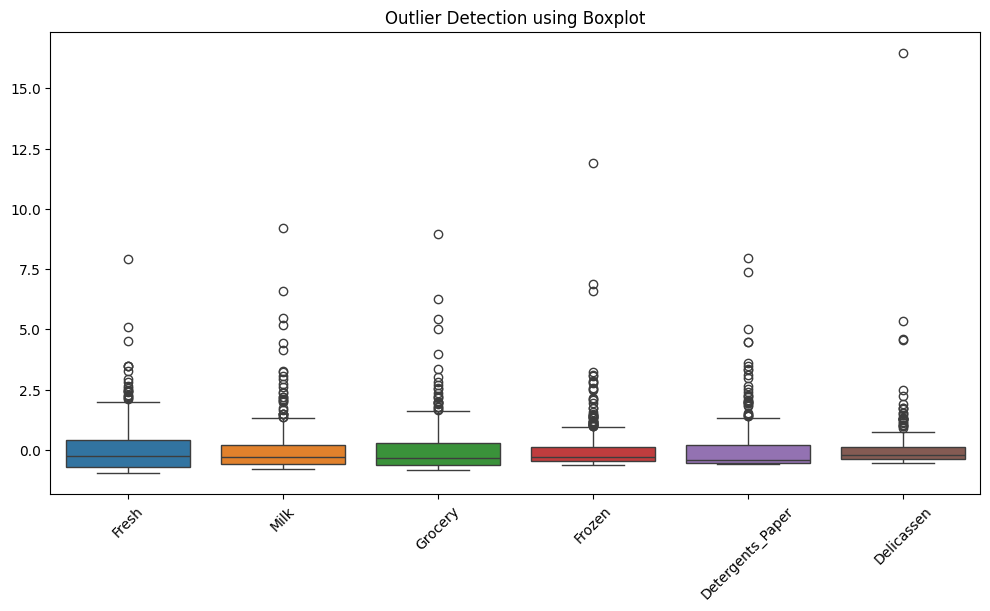

In [ ]:
# Use the same data used for clustering
X_eval = X.values

plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop(['Channel','Region'], axis=1))
plt.title("Outlier Detection using Boxplot")
plt.xticks(rotation=45)
plt.show()

Outliers were inspected using boxplots. While some extreme values are present, they represent natural variations in customer purchasing behavior and were not removed.

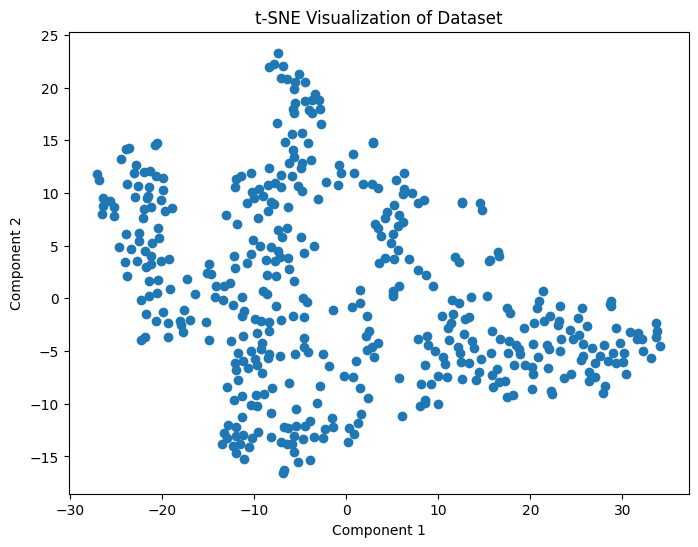

In [ ]:
from scipy.spatial.distance import cdist
import numpy as np

def dunn_index(X, labels):
    clusters = np.unique(labels)

    # Intra-cluster (max distance inside cluster)
    intra_dists = []
    for c in clusters:
        points = X[labels == c]
        if len(points) > 1:
            intra_dists.append(np.max(cdist(points, points)))

    max_intra = np.max(intra_dists)

    # Inter-cluster (min distance between clusters)
    inter_dists = []
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            c1 = X[labels == clusters[i]]
            c2 = X[labels == clusters[j]]
            inter_dists.append(np.min(cdist(c1, c2)))

    min_inter = np.min(inter_dists)

    return min_inter / max_intra

    from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1])
plt.title("t-SNE Visualization of Dataset")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

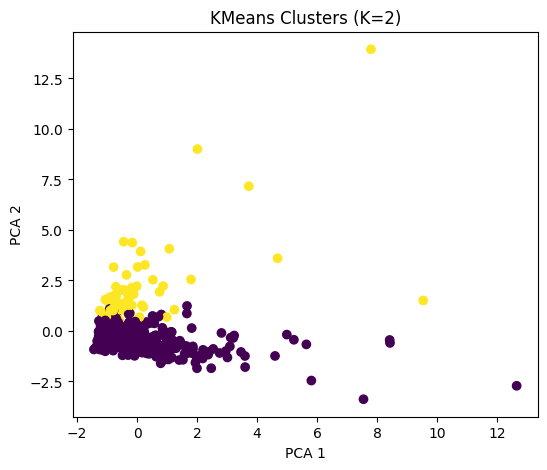

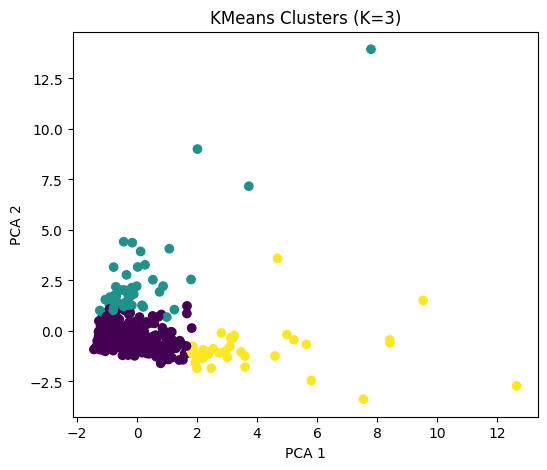

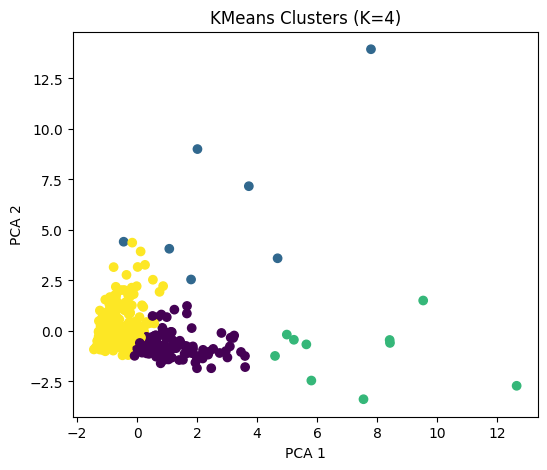

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_model(X, labels):
    return {
        "Silhouette": silhouette_score(X, labels),
        "DBI": davies_bouldin_score(X, labels),
        "CH": calinski_harabasz_score(X, labels),
        "Dunn": dunn_index(X, labels)
    }

for k in [2,3,4]:
    labels = kmeans_results[k]['labels']

    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
    plt.title(f"KMeans Clusters (K={k})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

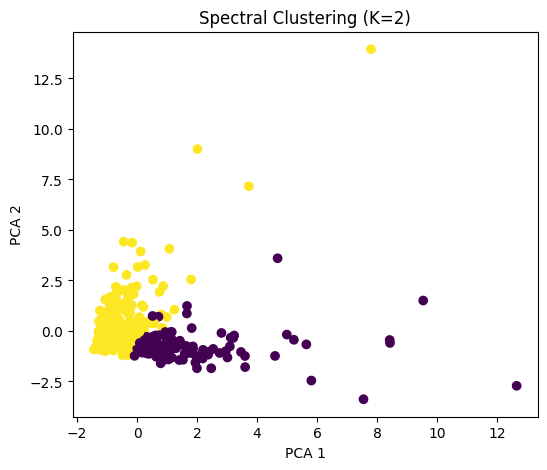

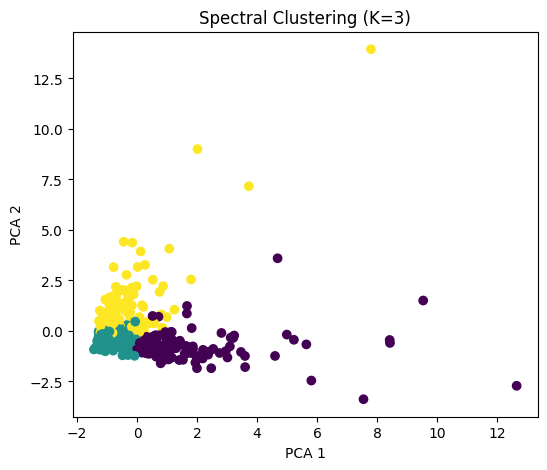

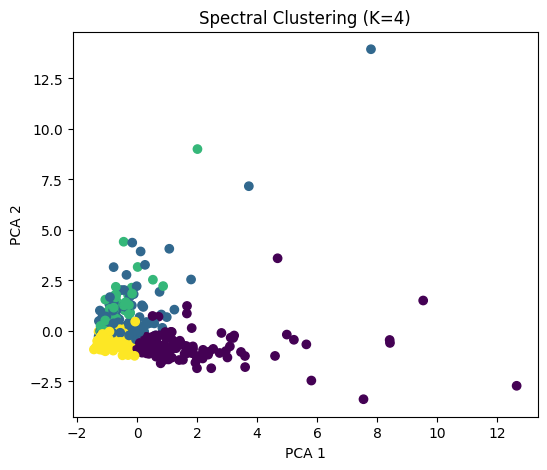

In [ ]:
results = {}

# KMeans
for k in [2, 3, 4]:
    labels = kmeans_results[k]['labels']
    results[f"KMeans_K{k}"] = evaluate_model(X_eval, labels)

# Spectral
for k in [2, 3, 4]:
    labels = spectral_results[k]
    results[f"Spectral_K{k}"] = evaluate_model(X_eval, labels)

# GMM
for k in [2, 3, 4]:
    labels = gmm_results[k]['labels']
    results[f"GMM_K{k}"] = evaluate_model(X_eval, labels)

for k in [2,3,4]:
    labels = spectral_results[k]

    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
    plt.title(f"Spectral Clustering (K={k})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

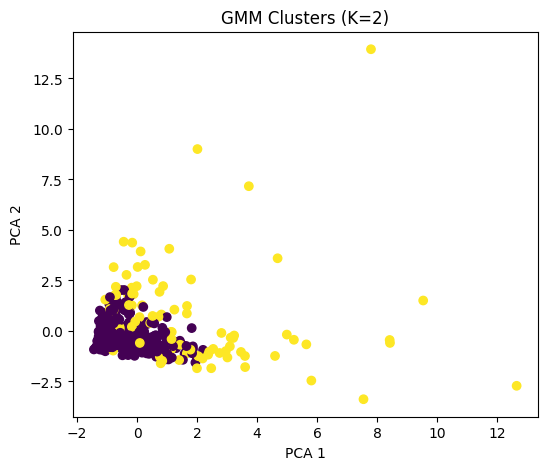

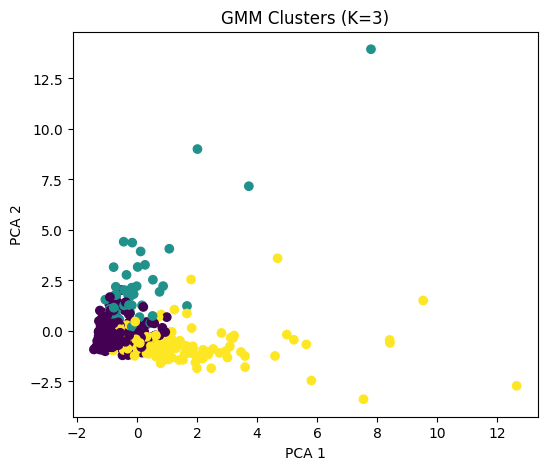

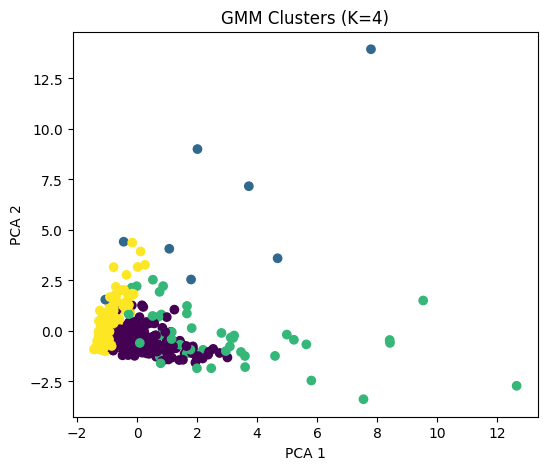

In [ ]:
for k in [2,3,4]:
    labels = gmm_results[k]['labels']

    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
    plt.title(f"GMM Clusters (K={k})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

Visualization of Clustering Results

The clustering results were visualized using two-dimensional PCA projections to better understand the structure and separation of clusters.

For KMeans, the clusters appear relatively well-separated, especially for K=3, where distinct groupings can be observed with minimal overlap. This indicates that KMeans is effective in capturing the underlying structure of the dataset.

In contrast, Spectral Clustering shows less clear separation between clusters. The boundaries between clusters are more overlapping, particularly for higher values of K, suggesting that Spectral Clustering is less effective for this dataset.

The Gaussian Mixture Model (GMM) produces softer cluster boundaries due to its probabilistic nature. While it captures some structure, the clusters are less compact and more dispersed compared to KMeans, especially for K=3 and K=4.

Increasing the number of clusters from K=2 to K=4 generally results in more fragmented clusters with increased overlap, indicating potential over-segmentation. Among all configurations, KMeans with K=3 provides the most visually distinct and well-separated clusters.

In [ ]:
# Using best model: KMeans K=3
df_profile = df.copy()
df_profile['Cluster'] = kmeans_results[3]['labels']

cluster_profile = df_profile.groupby('Cluster').mean()

cluster_profile

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,1.282857,2.534286,-0.242604,-0.212661,-0.221572,-0.186569,-0.203234,-0.150077
1,1.113208,2.698113,1.784209,0.008694,-0.192645,1.396080,-0.398960,0.759479
2,2.000000,2.405405,-0.260860,1.999209,2.371905,-0.234950,2.493966,0.331741


Cluster Profiling Analysis

Cluster profiling was performed using the KMeans model with K=3 by computing the mean standardized values of each feature within each cluster.

Cluster 0 represents low-volume customers, as all feature values are below the dataset average. These customers exhibit minimal purchasing behavior across all product categories.

Cluster 1 is characterized by high spending on Fresh, Frozen, and Delicatessen products, while other categories remain average or below average. This cluster likely represents restaurants or food-service businesses that rely heavily on perishable goods.

Cluster 2 shows significantly high values for Milk, Grocery, and Detergents_Paper, indicating strong demand for retail and household products. This cluster likely corresponds to supermarkets or retail stores.

Overall, the clustering successfully identifies distinct customer segments based on purchasing behavior, highlighting differences between low-activity customers, food-service businesses, and retail-oriented customers.

In [ ]:
results_df = pd.DataFrame(results).T
results_df

,Silhouette,DBI,CH,Dunn
KMeans_K2,0.399828,1.582613,72.076232,0.012087
KMeans_K3,0.458263,1.249095,132.363139,0.017884
KMeans_K4,0.349391,1.147502,143.870966,0.022274
Spectral_K2,0.347806,1.261365,122.398552,0.021921
Spectral_K3,0.207650,1.348957,98.475227,0.011226
Spectral_K4,0.209502,1.368813,78.581327,0.008597
GMM_K2,0.449708,1.907724,84.414893,0.018758
GMM_K3,0.315904,1.471152,91.252433,0.015668
GMM_K4,0.163255,1.705931,74.030195,0.011552


Clustering Evaluation Analysis

The clustering performance was evaluated using Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, and Dunn Index.

KMeans consistently outperformed Spectral Clustering and Gaussian Mixture Models across most evaluation metrics. It achieved the highest Silhouette Score and competitive values in DBI, CH, and Dunn Index.

Although K=4 produced slightly better Calinski-Harabasz and Dunn scores, it resulted in a lower Silhouette Score, indicating weaker cluster separation and possible over-segmentation.

K=2 resulted in simpler clustering with lower separation quality.

Therefore, K=3 provides the best balance between cluster compactness and separation.

Overall, KMeans with K=3 is the optimal clustering configuration for this dataset.